In [1]:
import pandas as pd
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import resample
import torch

PROJECT_ROOT = Path("..").resolve()
sys.path.append(str(PROJECT_ROOT))

from src.load_ecg import load_ecg, load_ecg_with_metadata

## Load Both Task Metadata Subsets & Load ECG

In [2]:
afib = pd.read_parquet("../data/processed/afib_subset_metadata.parquet")
norm = pd.read_parquet("../data/processed/norm_subset_metadata.parquet")

In [3]:
example_path = afib['waveform_path'][0]

In [4]:
signal, fs = load_ecg(example_path)
signal.shape

(5000, 12)

## Preprocess for HuBERT-ECG

In [5]:
def _zscore_per_lead(x_5s: np.ndarray, eps: float = 1e-6) -> np.ndarray:
    """
    x_5s: (500, 12)
    returns: (12, 500) float32
    """
    # Optional: prevent NaNs/Infs from propagating
    x_5s = np.nan_to_num(x_5s, nan=0.0, posinf=0.0, neginf=0.0)

    mu = x_5s.mean(axis=0, keepdims=True)
    sd = x_5s.std(axis=0, keepdims=True) + eps
    x_norm = (x_5s - mu) / sd
    return x_norm.T.astype(np.float32)  # (12, 500)

def preprocess_for_hubert(x_10s: np.ndarray, fs: float) -> np.ndarray:
    """
      x_10s: (5000, 12)
      returns: (2, 12, 500) float32
              clip 0 = first 5s, clip 1 = second 5s (after resampling to 100 Hz)
    """
    target_fs = 100.0

    # resample to 100 Hz
    resamp_x = int(round(x_10s.shape[0] * target_fs / fs))
    resamp_x = resample(x_10s, resamp_x, axis=0).astype(np.float32)  # (resample_x, 12)

    crop_len = int(5 * target_fs)  # 500 samples @ 100 Hz

    # Take first and second contiguous 5s chunks
    x_5s_a = resamp_x[:crop_len]      # (500, 12)
    x_5s_b = resamp_x[crop_len:]      # (500, 12)

    clip_a = _zscore_per_lead(x_5s_a)  # (12, 500)
    clip_b = _zscore_per_lead(x_5s_b)  # (12, 500)

    return np.stack([clip_a, clip_b], axis=0)      # (2, 12, 500)

### Import HuBERT-ECG

In [6]:
# Importing HuBERT-ECG
from transformers import AutoModel

def load_hubert_ecg(device="cpu"):
    model = AutoModel.from_pretrained(
        "Edoardo-BS/hubert-ecg-small",
        trust_remote_code=True
    ).to(device)
    model.eval()
    return model

device = 'cpu'
hubert = load_hubert_ecg(device)

# Encodes raw MIMIC-IV-ECG into embeddings
@torch.no_grad()
def hubert_encode(x_half: np.ndarray, hubert_model, device="cpu") -> torch.Tensor:
    """
    x_half: (12, 500) numpy
    returns: (1, 512) torch
    """
    x = torch.tensor(
        x_half.reshape(1, -1),  # (1, 6000)
        dtype=torch.float32,
        device=device
    )

    out = hubert_model(x)
    z = out.last_hidden_state.mean(dim=1)  # (1, D)
    return z.cpu()

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

In [7]:
x_halves = preprocess_for_hubert(signal, fs)
x_halves.shape

(2, 12, 500)

In [8]:
emb1 = hubert_encode(x_halves[0], hubert, device)
emb2 = hubert_encode(x_halves[1], hubert, device)

emb = (emb1 + emb2) / 2
emb.shape

torch.Size([1, 512])

### Extraction Loop + Saving w/ Checkpoints

In [9]:
from tqdm.auto import tqdm

In [10]:
emb_path = PROJECT_ROOT / 'data' / 'processed' / 'embeddings'
afib_emb_path = emb_path / 'afib_subset_embeddings.parquet'
norm_emb_path = emb_path / 'norm_subset_embeddings.parquet'

In [11]:
def encode_ecg_record(row, encoder, device='cpu'):
    signal, fs = load_ecg(row['waveform_path'])

    x_halves = preprocess_for_hubert(signal, fs)

    emb1 = hubert_encode(x_halves[0], encoder, device)
    emb2 = hubert_encode(x_halves[1], encoder, device)

    emb = (emb1 + emb2) / 2
    return emb

In [12]:
def build_embeddings_table(df, out_path, model, device='cpu'):
    buffer = []
    
    for _, row in tqdm(df.iterrows(), total=len(df)):
        record = {
            'file_name': row['file_name'],
            'waveform_path': row['waveform_path']
        }
    
        try:
            emb = encode_ecg_record(row, encoder=model, device=device).squeeze(0).cpu().numpy().astype(np.float32)
    
            record["embedding"] = emb.tolist()
            record["embedding_dim"] = int(len(emb))
            record["status"] = "ok"
            record["error"] = None
    
        except Exception as e:
            record["embedding"] = None
            record["embedding_dim"] = None
            record["status"] = "failed"
            record["error"] = str(e)
    
        buffer.append(record)
    
        if len(buffer) >= 50:
            chunk = pd.DataFrame(buffer)
    
            if out_path.exists():
                prev = pd.read_parquet(out_path)
                merged = pd.concat([prev, chunk], ignore_index=True)
                merged = merged.drop_duplicates(subset=['waveform_path'], keep="last")
                merged.to_parquet(out_path, index=False)
            else:
                chunk.to_parquet(out_path, index=False)
    
            print(f"Saved {len(chunk)} rows to {out_path.name}")
            buffer = []
    
    # final flush
    if buffer:
        chunk = pd.DataFrame(buffer)
    
        if out_path.exists():
            prev = pd.read_parquet(out_path)
            merged = pd.concat([prev, chunk], ignore_index=True)
            merged = merged.drop_duplicates(subset=['waveform_path'], keep="last")
            merged.to_parquet(out_path, index=False)
        else:
            chunk.to_parquet(out_path, index=False)
    
        print(f"Saved final {len(chunk)} rows to {out_path.name}")
    
    print("Done.")
    print("Final output:", out_path)

In [14]:
build_embeddings_table(afib, afib_emb_path, hubert)

  0%|          | 0/10000 [00:00<?, ?it/s]

Saved 50 rows to afib_subset_embeddings.parquet
Saved 50 rows to afib_subset_embeddings.parquet
Saved 50 rows to afib_subset_embeddings.parquet
Saved 50 rows to afib_subset_embeddings.parquet
Saved 50 rows to afib_subset_embeddings.parquet
Saved 50 rows to afib_subset_embeddings.parquet
Saved 50 rows to afib_subset_embeddings.parquet
Saved 50 rows to afib_subset_embeddings.parquet
Saved 50 rows to afib_subset_embeddings.parquet
Saved 50 rows to afib_subset_embeddings.parquet
Saved 50 rows to afib_subset_embeddings.parquet
Saved 50 rows to afib_subset_embeddings.parquet
Saved 50 rows to afib_subset_embeddings.parquet
Saved 50 rows to afib_subset_embeddings.parquet
Saved 50 rows to afib_subset_embeddings.parquet
Saved 50 rows to afib_subset_embeddings.parquet
Saved 50 rows to afib_subset_embeddings.parquet
Saved 50 rows to afib_subset_embeddings.parquet
Saved 50 rows to afib_subset_embeddings.parquet
Saved 50 rows to afib_subset_embeddings.parquet
Saved 50 rows to afib_subset_embeddings.

In [15]:
build_embeddings_table(norm, norm_emb_path, hubert)

  0%|          | 0/10000 [00:00<?, ?it/s]

Saved 50 rows to norm_subset_embeddings.parquet
Saved 50 rows to norm_subset_embeddings.parquet
Saved 50 rows to norm_subset_embeddings.parquet
Saved 50 rows to norm_subset_embeddings.parquet
Saved 50 rows to norm_subset_embeddings.parquet
Saved 50 rows to norm_subset_embeddings.parquet
Saved 50 rows to norm_subset_embeddings.parquet
Saved 50 rows to norm_subset_embeddings.parquet
Saved 50 rows to norm_subset_embeddings.parquet
Saved 50 rows to norm_subset_embeddings.parquet
Saved 50 rows to norm_subset_embeddings.parquet
Saved 50 rows to norm_subset_embeddings.parquet
Saved 50 rows to norm_subset_embeddings.parquet
Saved 50 rows to norm_subset_embeddings.parquet
Saved 50 rows to norm_subset_embeddings.parquet
Saved 50 rows to norm_subset_embeddings.parquet
Saved 50 rows to norm_subset_embeddings.parquet
Saved 50 rows to norm_subset_embeddings.parquet
Saved 50 rows to norm_subset_embeddings.parquet
Saved 50 rows to norm_subset_embeddings.parquet
Saved 50 rows to norm_subset_embeddings.

In [37]:
afib_emb = pd.read_parquet(afib_emb_path)
afib_emb['error'].nunique()

0

In [38]:
norm_emb = pd.read_parquet(norm_emb_path)
norm_emb['error'].nunique()

0

In [39]:
afib_emb.head()

,file_name,waveform_path,embedding,embedding_dim,status,error
0,45808859,../data/raw_waveforms/files/p1000/p10001860/s4...,"[-0.9942229986190796, 0.2552224397659302, -0.4...",512,ok,None
1,41748669,../data/raw_waveforms/files/p1000/p10002157/s4...,"[-1.1261041164398193, -0.22388218343257904, -0...",512,ok,None
2,45036862,../data/raw_waveforms/files/p1000/p10003400/s4...,"[-0.6866012811660767, 0.42761075496673584, -0....",512,ok,None
3,47684518,../data/raw_waveforms/files/p1000/p10003400/s4...,"[0.5916447043418884, 0.9548905491828918, -0.32...",512,ok,None
4,47771850,../data/raw_waveforms/files/p1000/p10003400/s4...,"[0.653958797454834, 0.8167142271995544, -0.398...",512,ok,None


### Expanding Embeddings for ML Use

In [41]:
afib_emb = afib_emb[['file_name', 'waveform_path', 'embedding']]
norm_emb = norm_emb[['file_name', 'waveform_path', 'embedding']]

In [42]:
def flatten_embedding(x):
    arr = np.array(x, dtype=np.float32)
    return arr.reshape(-1)

def add_expanded_embedding_columns(df, embedding_col="embedding", prefix="emb_"):
    emb_matrix = np.vstack(df[embedding_col].apply(flatten_embedding).values).astype(np.float32)
    emb_cols = [f"{prefix}{i}" for i in range(emb_matrix.shape[1])]
    emb_df = pd.DataFrame(emb_matrix, columns=emb_cols, index=df.index)
    return pd.concat([df.reset_index(drop=True), emb_df.reset_index(drop=True)], axis=1)

In [43]:
afib_emb_expanded = add_expanded_embedding_columns(afib_emb, embedding_col="embedding", prefix="emb_")
norm_emb_expanded = add_expanded_embedding_columns(norm_emb, embedding_col="embedding", prefix="emb_")

print("afib_emb_expanded:", afib_emb_expanded.shape)
print("norm_emb_expanded:", norm_emb_expanded.shape)

afib_emb_expanded: (10000, 515)
norm_emb_expanded: (10000, 515)


In [44]:
afib_emb_expanded.to_parquet(emb_path/'afib_subset_embeddings_exp.parquet', index=False)
norm_emb_expanded.to_parquet(emb_path/'norm_subset_embeddings_exp.parquet', index=False)

### Quick Visualizations

In [46]:
X = np.vstack(afib_emb["embedding"].values)

print(X.shape)

(10000, 512)


In [47]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X)

print(X_pca.shape)

(10000, 2)


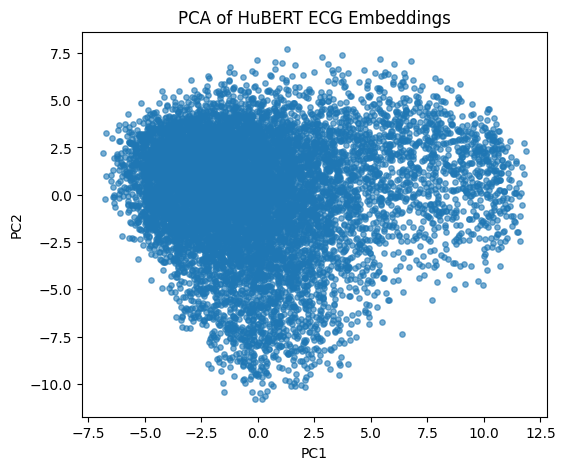

In [48]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))

plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    alpha=0.6,
    s=15
)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA of HuBERT ECG Embeddings")

plt.show()

In [50]:
print("Explained variance ratio:", pca.explained_variance_ratio_)
print("Total variance explained:", pca.explained_variance_ratio_.sum())

Explained variance ratio: [0.26208512 0.18494252]
Total variance explained: 0.4470276420663954


In [53]:
norms = np.linalg.norm(X, axis=1)

print("Mean norm:", norms.mean())
print("Std norm:", norms.std())

Mean norm: 12.771106161557883
Std norm: 0.9823524102649318


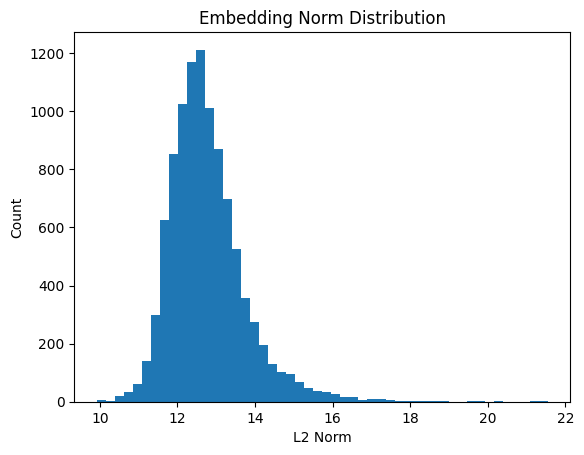

In [54]:
import matplotlib.pyplot as plt

plt.hist(norms, bins=50)
plt.title("Embedding Norm Distribution")
plt.xlabel("L2 Norm")
plt.ylabel("Count")
plt.show()